In [1]:
import numpy as np
from numpy import ndarray, int64
import torch

Firstly, we import the data from the data folder. We load the data, only the one needed for task 1. In this case, we want to do a binary classification, so we should add the binary parameter. 

In [ ]:
import os
from pathlib import Path
from galaxyzoo.data import load_data

img_path = Path("data/images")
labels_path = Path("data/labels.csv")

# Load the data
image_paths, labels_class = load_data(img_path, labels_path, task="task1", binary=True)

## Preprocessing
We split the data into train, validation and test sets. 

In [ ]:
from sklearn.model_selection import train_test_split

train_images, temp_images, train_labels, temp_labels = train_test_split(
    image_paths,
    labels_class,
    test_size=0.3,
    random_state=42,
    stratify=labels_class   # split to mantain the imbalance
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f'Training size: {len(train_labels)} ({len(train_labels)/len(labels_class)*100:.0f}%)')
print(f'Validation size: {len(val_labels)} ({len(val_labels)/len(labels_class)*100:.0f}%)')
print(f'Test size: {len(test_labels)} ({len(test_labels)/len(labels_class)*100:.0f}%)')

Training size: 21427 (70%)
Validation size: 4591 (15%)
Test size: 4592 (15%)


In order to obtain the mean and the standard deviation, we use a stats datasets to compute them. 

In [ ]:
from torchvision import transforms
from galaxyzoo.data import GalaxiesDataset
from torch.utils.data import DataLoader
import torch

dim_pixels = 96

# Compute per-channel mean and std on the training set (needed for Normalize)
stats_transform = transforms.Compose([
    transforms.CenterCrop(220),
    transforms.Resize((dim_pixels, dim_pixels)),
    transforms.ToTensor(),
])
stats_dataset = GalaxiesDataset(train_images, train_labels, transform=stats_transform, task="binary_class")
stats_loader = DataLoader(stats_dataset, batch_size=256, shuffle=False)

mean = torch.zeros(3)
std = torch.zeros(3)
for imgs, _ in stats_loader:
    mean += imgs.mean(dim=[0, 2, 3])
    std += imgs.std(dim=[0, 2, 3])
mean /= len(stats_loader)
std /= len(stats_loader)

print(f"Mean: {mean.tolist()}")
print(f"Std:  {std.tolist()}")

Mean: [0.09112106263637543, 0.07949503511190414, 0.06306508928537369]
Std:  [0.13500215113162994, 0.11366653442382812, 0.09954772889614105]


Next, we create a dataset for each set. We use a different transformation for the training set, to increase the performance.

In [ ]:
train_transform = transforms.Compose([
    transforms.CenterCrop(220),
    transforms.Resize((dim_pixels, dim_pixels)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
])

validation_test_transform = transforms.Compose([
    transforms.CenterCrop(220),
    transforms.Resize((dim_pixels, dim_pixels)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
])

train_dataset = GalaxiesDataset(train_images, train_labels, 
                                transform=train_transform, task="binary_class")
validation_dataset = GalaxiesDataset(val_images, val_labels, 
                                     transform=validation_test_transform, task="binary_class")
test_dataset = GalaxiesDataset(test_images, test_labels, 
                               transform=validation_test_transform, task="binary_class")

Then, we transform the dataset to dataloader of training, validation and test data. 

In [6]:
from torch.utils.data import DataLoader

batch_size=64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Training and fitting
After the preprocessing, we just need to specify the parameters of the model and fit the data. For the training we just use the training and validation sets. 

In [ ]:
from torch import nn
from torch.optim import Adam
from galaxyzoo.cnn import CNN
from galaxyzoo.training_utils import fit
from torch.optim.lr_scheduler import ReduceLROnPlateau

in_channels = 3     # RGB
out_channels = 1    # binary classification, only one output

cnn_model = CNN(
    in_channels=in_channels,
    out_channels=out_channels,
    input_shape=(dim_pixels, dim_pixels),
    hidden_channels=16,
    final_hidden_channels=64,
    activation="relu",
)

cnn_optimizer = Adam(cnn_model.parameters(), lr=1e-3)
loss_function = nn.BCEWithLogitsLoss()
epochs = 20

scheduler = ReduceLROnPlateau(
    cnn_optimizer,
    mode='min',
    factor=0.5,
    patience=2,
)

train_losses, val_losses, train_accuracies, val_accuracies = fit(
    epochs=epochs,
    loss_function=loss_function,
    model=cnn_model,
    optimizer=cnn_optimizer,
    train_loader=train_loader,
    validation_loader=validation_loader,
    scheduler=scheduler,
    include_accuracy=True,
    task="binary_class"
)

-------------------------------
| Epoch 1                     |
| Train loss: 0.2548          |
| Validation loss: 1.4997     |
| Train accuracy: 90.25%      |
| Validation accuracy: 59.44% |
| Learning rate: 1.00e-03     |
-------------------------------
-------------------------------
| Epoch 2                     |
| Train loss: 0.1639          |
| Validation loss: 0.2667     |
| Train accuracy: 94.13%      |
| Validation accuracy: 90.24% |
| Learning rate: 1.00e-03     |
-------------------------------
-------------------------------
| Epoch 3                     |
| Train loss: 0.1287          |
| Validation loss: 0.1458     |
| Train accuracy: 95.26%      |
| Validation accuracy: 94.77% |
| Learning rate: 1.00e-03     |
-------------------------------
-------------------------------
| Epoch 4                     |
| Train loss: 0.1133          |
| Validation loss: 0.1022     |
| Train accuracy: 95.85%      |
| Validation accuracy: 96.38% |
| Learning rate: 1.00e-03     |
--------

We plot the loss and the accuracy, as it is better visualized. 

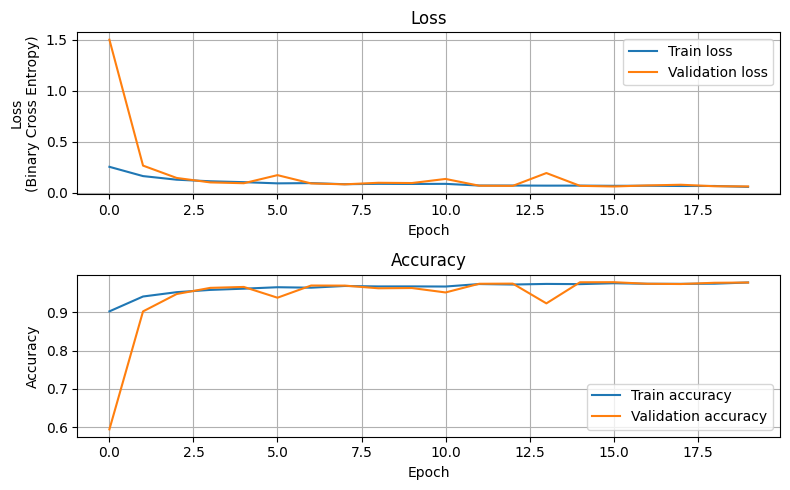

In [8]:
import matplotlib.pyplot as plt

#plot the figure
fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(8)

ax1 = plt.subplot(2,1,1)
ax1.plot(train_losses, label="Train loss")
ax1.plot(val_losses, label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss\n(Binary Cross Entropy)")
ax1.set_title("Loss")
ax1.legend()
ax1.grid()

ax2 = plt.subplot(2,1,2)
ax2.plot(train_accuracies, label="Train accuracy")
ax2.plot(val_accuracies, label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid()

plt.tight_layout()

## Evaluation
Finally, we evaluate the model with the test data. We will compute the confusion matrix and the ROC curves. 

In [9]:
import torch.nn.functional as F

labels_test = []
labels_preds = []
labels_probs = []

with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = cnn_model(imgs).flatten()
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        labels_test.extend(labels.cpu().numpy())
        labels_preds.extend(preds.cpu().numpy())
        labels_probs.extend(probs.cpu().numpy())

### Confusion matrix
We compute and plot the confusion matrix.

Text(0.5, 1.0, 'Confusion Matrix')

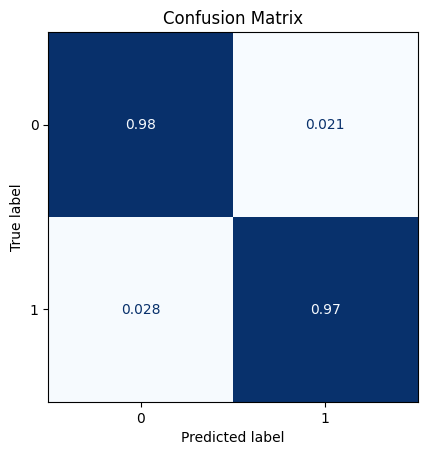

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(labels_test, labels_preds, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

disp.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")

### ROC curves
We also compute the ROC curve, only one curve for binary classification. 

Text(0.5, 1.0, 'ROC curve')

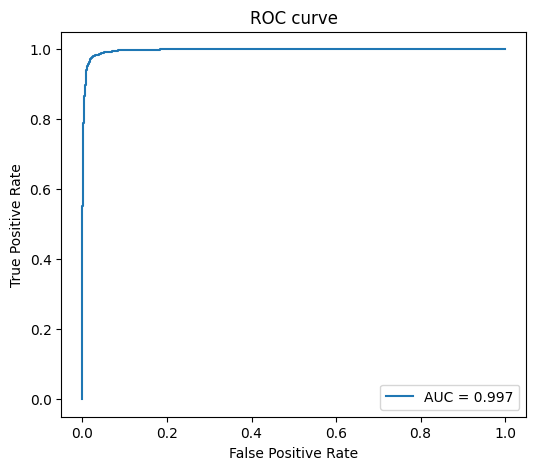

In [ ]:
from sklearn.metrics import roc_curve, auc

labels_test = np.array(labels_test)
labels_probs = np.array(labels_probs)

# Plot the figure
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(6)

fpr, tpr, _ = roc_curve(labels_test, labels_probs)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
ax.legend()
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve")